In [1]:
# Import relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Load Data for Seattle

In [3]:
df_sea = pd.read_csv("https://raw.githubusercontent.com/binay8/weather/refs/heads/master/data/seattle_data.csv")

In [4]:
df_sea.head(10)

,STATION,NAME,DATE,PRCP,SNOW,SNWD
0,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",1/1/2018,0.00,0.0,0.0
1,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",1/2/2018,0.00,0.0,0.0
2,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",1/3/2018,0.00,0.0,0.0
3,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",1/4/2018,0.13,0.0,0.0
4,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",1/5/2018,0.51,0.0,0.0
5,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",1/6/2018,0.17,0.0,0.0
6,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",1/7/2018,0.33,0.0,0.0
7,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",1/8/2018,0.16,0.0,0.0
8,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",1/9/2018,0.18,0.0,0.0
9,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",1/10/2018,0.17,0.0,0.0


## Load Data for Charlotte

In [5]:
df_cha = pd.read_csv("https://raw.githubusercontent.com/binay8/weather/refs/heads/master/data/charlotte_data.csv")

In [6]:
df_cha.head(10)

,STATION,NAME,DATE,PRCP,SNOW,SNWD
0,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",1/1/2018,0.00,0.0,0.0
1,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",1/2/2018,0.00,0.0,0.0
2,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",1/3/2018,0.00,0.0,0.0
3,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",1/4/2018,0.00,0.0,0.0
4,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",1/5/2018,0.00,0.0,0.0
5,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",1/6/2018,0.00,0.0,0.0
6,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",1/7/2018,0.00,0.0,0.0
7,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",1/8/2018,0.04,0.0,0.0
8,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",1/9/2018,0.00,0.0,0.0
9,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",1/10/2018,0.00,0.0,0.0


## Review available columns for both datasets

In [7]:
df_sea.columns

Index(['STATION', 'NAME', 'DATE', 'PRCP', 'SNOW', 'SNWD'], dtype='str')

In [8]:
df_cha.columns

Index(['STATION', 'NAME', 'DATE', 'PRCP', 'SNOW', 'SNWD'], dtype='str')

## Using df.info() to review additional information about our data set
Looking for potential missing or incomplete data, review how many rows, data type, null values....

In [9]:
df_sea.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1826 non-null   str    
 1   NAME     1826 non-null   str    
 2   DATE     1826 non-null   str    
 3   PRCP     1823 non-null   float64
 4   SNOW     1826 non-null   float64
 5   SNWD     1826 non-null   float64
dtypes: float64(3), str(3)
memory usage: 173.0 KB


In [10]:
df_cha.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1826 non-null   str    
 1   NAME     1826 non-null   str    
 2   DATE     1826 non-null   str    
 3   PRCP     1826 non-null   float64
 4   SNOW     1826 non-null   float64
 5   SNWD     1826 non-null   float64
dtypes: float64(3), str(3)
memory usage: 178.4 KB


## Review Station Details
Ideally only one station per city.

In [11]:
print(df_sea['STATION'].unique())
print(df_cha['STATION'].unique())

<ArrowStringArray>
['USW00024233']
Length: 1, dtype: str
<ArrowStringArray>
['USW00013881']
Length: 1, dtype: str


## Start data cleanup/clense

Initial impression is that attributes Name and Stations is redudant. Hence, we may only need to keep one attribute. Let's confirm

In [12]:
print(df_sea['NAME'].nunique())
print(df_cha['NAME'].nunique())

1
1


We also don't need SNOW, and SNWD attributes as this analysis is solely focused on precipitation data

In [13]:
df_sea, df_cha = df_sea[['STATION', 'DATE', 'PRCP']], df_cha[['STATION', 'DATE', 'PRCP']]

In [14]:
df_sea.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1826 non-null   str    
 1   DATE     1826 non-null   str    
 2   PRCP     1823 non-null   float64
dtypes: float64(1), str(2)
memory usage: 78.5 KB


In [15]:
df_cha.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1826 non-null   str    
 1   DATE     1826 non-null   str    
 2   PRCP     1826 non-null   float64
dtypes: float64(1), str(2)
memory usage: 78.5 KB


## Address data type
Fix data type of "DATE" from str to datetime using pd.to_datetime()

In [16]:
df_sea['DATE'] = pd.to_datetime(df_sea['DATE'])

In [17]:
df_sea.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   STATION  1826 non-null   str           
 1   DATE     1826 non-null   datetime64[us]
 2   PRCP     1823 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 62.5 KB


In [18]:
df_cha['DATE'] = pd.to_datetime(df_cha['DATE'])

In [19]:
df_cha.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   STATION  1826 non-null   str           
 1   DATE     1826 non-null   datetime64[us]
 2   PRCP     1826 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 62.5 KB


In [20]:
print(f"Min, Max date for Seattle dataset:\nMin = {df_sea['DATE'].min()}\nMax = {df_sea['DATE'].max()}")

Min, Max date for Seattle dataset:
Min = 2018-01-01 00:00:00
Max = 2022-12-31 00:00:00


In [21]:
print(f"Min, Max date for Charlotte dataset:\nMin = {df_cha['DATE'].min()}\nMax = {df_cha['DATE'].max()}")

Min, Max date for Charlotte dataset:
Min = 2018-01-01 00:00:00
Max = 2022-12-31 00:00:00


### Plot Percipitation data for Seattle


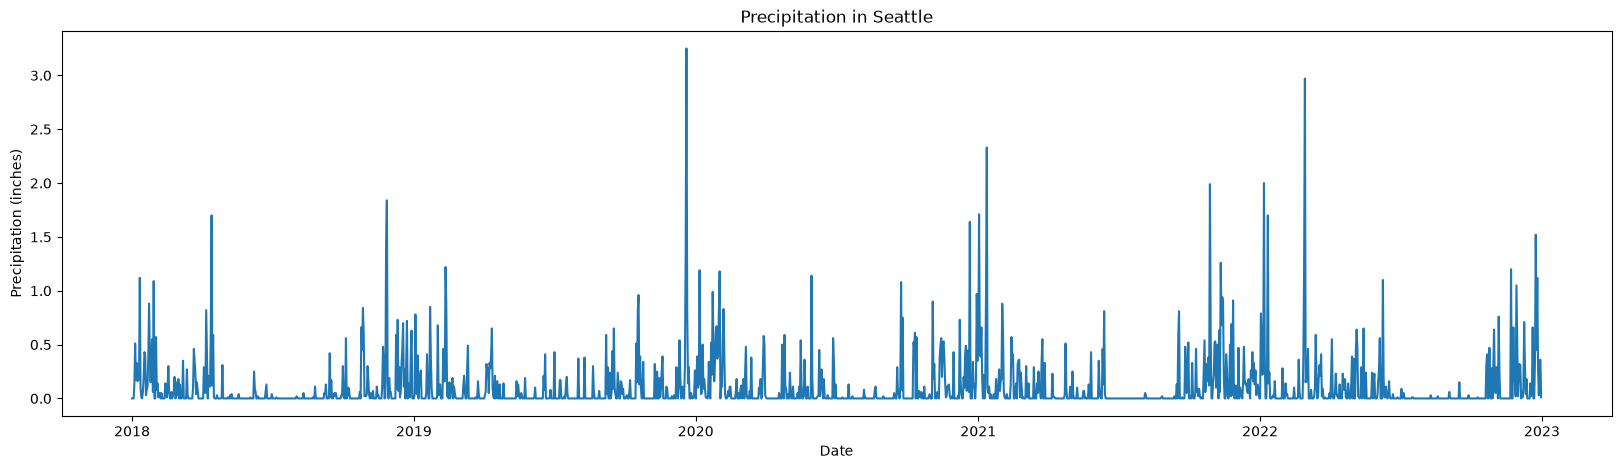

In [31]:
plt.figure(figsize=(20,5))
plt.title("Precipitation in Seattle")
sns.lineplot(data = df_sea, x = "DATE", y = "PRCP")
plt.xlabel("Date")
plt.ylabel("Precipitation (inches)")
plt.show()

### Plot Precipitation data for Charlotte

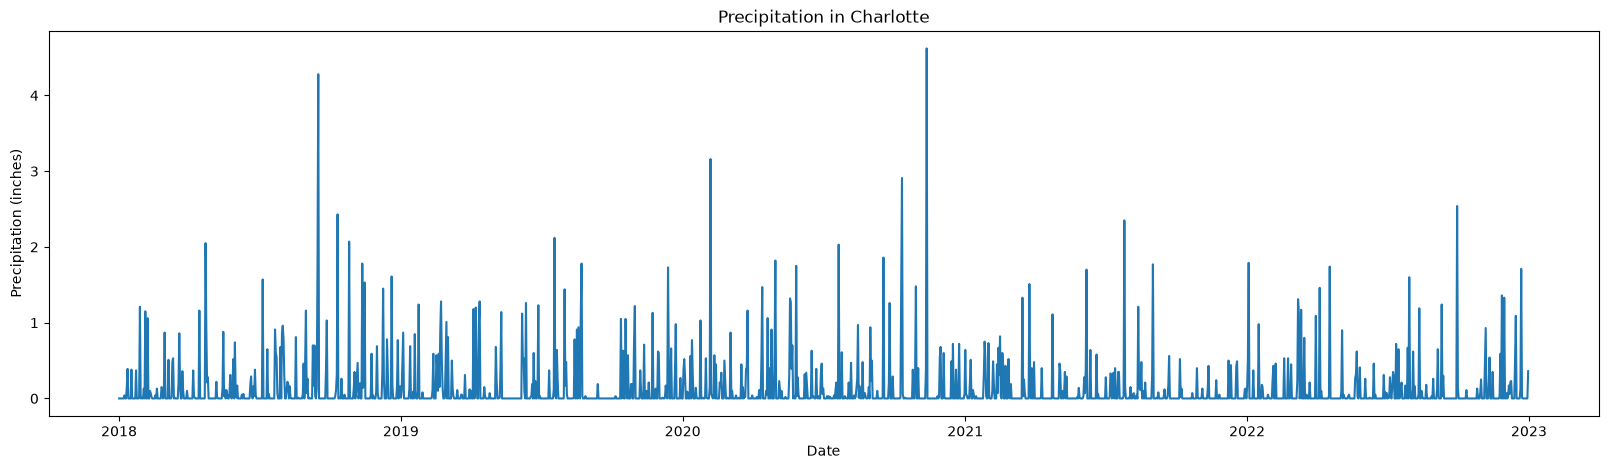

In [32]:
plt.figure(figsize=(20,5))
plt.title("Precipitation in Charlotte")
sns.lineplot(data = df_cha, x = "DATE", y = "PRCP")
plt.xlabel("Date")
plt.ylabel("Precipitation (inches)")
plt.show()

In [33]:
df_sea.describe()

,DATE,PRCP
count,1826,1823.000000
mean,2020-07-01 12:00:00,0.107071
min,2018-01-01 00:00:00,0.000000
25%,2019-04-02 06:00:00,0.000000
50%,2020-07-01 12:00:00,0.000000
75%,2021-09-30 18:00:00,0.100000
max,2022-12-31 00:00:00,3.250000
std,NaN,0.252325


In [34]:
df_cha.describe()

,DATE,PRCP
count,1826,1826.000000
mean,2020-07-01 12:00:00,0.138001
min,2018-01-01 00:00:00,0.000000
25%,2019-04-02 06:00:00,0.000000
50%,2020-07-01 12:00:00,0.000000
75%,2021-09-30 18:00:00,0.060000
max,2022-12-31 00:00:00,4.620000
std,NaN,0.365697
